## Predicted Building Damage: Colombia Earthquake 2026

Following the August 2026 earthquake in Colombia, the [Microsoft AI for Good Lab](https://www.microsoft.com/en-us/research/group/ai-for-good-research-lab/) trained and ran a building-damage-assessment model over post-event satellite imagery. The model classifies every building footprint in the imagery as *undamaged*, *damaged*, or *unknown* (for example, when the building is obscured by cloud or haze).

This notebook explores the [`predicted-damage-colombia-2026`](https://planetarycomputer.microsoft.com/dataset/predicted-damage-colombia-2026) collection on the Planetary Computer. Unlike the [companion Venezuela collection](https://planetarycomputer.microsoft.com/dataset/predicted-damage-venezuela-2026), which publishes a single collection-level file, this collection has one **STAC item per assessed city**, and each item carries several assets:

| Asset | Format | What it is |
| --- | --- | --- |
| `overture-buildings` | GeoPackage | [Overture Maps](https://overturemaps.org/) footprints with predicted damage |
| `google-buildings` | GeoPackage | [Google Open Buildings](https://sites.research.google/gr/open-buildings/) footprints with predicted damage |
| `visual` | Cloud-Optimized GeoTIFF | The model's per-pixel prediction raster |
| `valid-area-mask` | GeoJSON | Outline of the area the assessment covers |

We'll **query** the STAC API for the items, **load** the GeoPackages into a `geopandas.GeoDataFrame`, and **plot** the results — first as city-wide overview maps, then as a close-up of the prediction raster.

The collection mirrors the datasets published by the AI for Good Lab on the [Humanitarian Data Exchange](https://data.humdata.org/) and is made available under the [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/) license.


In [1]:
import os
import tempfile

import fsspec
import geopandas
import matplotlib.pyplot as plt
import pandas as pd
import planetary_computer
import pystac_client
import rasterio
import rasterio.windows


### Querying the STAC API

The datasets hosted by the Planetary Computer live in [Azure Blob Storage](https://learn.microsoft.com/azure/storage/blobs/). We use [`pystac-client`](https://pystac-client.readthedocs.io/) to open the [STAC API](https://planetarycomputer.microsoft.com/api/stac/v1) and pass `modifier=planetary_computer.sign_inplace` so that asset hrefs are automatically [signed](https://planetarycomputer.microsoft.com/docs/concepts/sas/) with a short-lived token. That token is what lets us read the data out of the Planetary Computer's private blob container.


In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(collections=["predicted-damage-colombia-2026"])
items = sorted(search.item_collection(), key=lambda item: item.datetime)

pd.DataFrame(
    [
        {
            "id": item.id,
            "datetime": item.datetime,
            "bbox": [round(v, 3) for v in item.bbox],
            "assets": list(item.assets),
        }
        for item in items
    ]
)


,id,datetime,bbox,assets
0,cali-2026-08-10,2026-08-10 00:00:00+00:00,"[-76.615, 3.413, -76.459, 3.548]","[visual, valid-area-mask, google-buildings, ov..."
1,pereira-2026-08-12,2026-08-12 00:00:00+00:00,"[-75.786, 4.776, -75.692, 4.843]","[visual, valid-area-mask, google-buildings, ov..."


Two items, one for each assessed city: **Cali** and **Pereira**. Because a STAC search accepts spatial and temporal filters, you can also ask for just the area or date range you care about — for example, the Pereira item only:


In [3]:
pereira_search = catalog.search(
    collections=["predicted-damage-colombia-2026"],
    bbox=[-75.79, 4.77, -75.69, 4.85],
)
[item.id for item in pereira_search.items()]


['pereira-2026-08-12']

### The item assets

Each item bundles the two footprint GeoPackages, the prediction raster, and the valid-area mask. The `tilejson` and `rendered_preview` entries are added by the Planetary Computer API itself, and give you a web-map tile endpoint and a quick-look PNG of the raster without downloading anything.


In [4]:
pd.DataFrame(
    [
        {
            "item": item.id,
            "asset": key,
            "media type": asset.media_type,
            "file": os.path.basename(asset.href.split("?")[0]),
        }
        for item in items
        for key, asset in item.assets.items()
    ]
)


,item,asset,media type,file
0,cali-2026-08-10,visual,image/tiff; application=geotiff; profile=cloud...,airbus_cali_warped_cog_model-predictions.tif
1,cali-2026-08-10,valid-area-mask,application/geo+json,airbus_8-10_cali_valid_area_mask.geojson
2,cali-2026-08-10,google-buildings,application/geopackage+sqlite3,airbus_8-10_cali_hdx_building_footprints_with_...
3,cali-2026-08-10,overture-buildings,application/geopackage+sqlite3,airbus_8-10_cali_overture_building_footprints_...
4,cali-2026-08-10,tilejson,application/json,tilejson.json
5,cali-2026-08-10,rendered_preview,image/png,preview.png
6,pereira-2026-08-12,visual,image/tiff; application=geotiff; profile=cloud...,vantor_8-12_pereira_model-predictions.tif
7,pereira-2026-08-12,valid-area-mask,application/geo+json,vantor_8-12_pereira_valid_area_mask.geojson
8,pereira-2026-08-12,google-buildings,application/geopackage+sqlite3,vantor_8-12_pereira_google_buildings_with_pred...
9,pereira-2026-08-12,overture-buildings,application/geopackage+sqlite3,vantor_8-12_pereira_overture_buildings_with_pr...


### Loading the footprints into a `GeoDataFrame`

A GeoPackage is a single [SQLite](https://www.sqlite.org/) database file. Unlike a Parquet dataset it can't be efficiently range-read in place through GDAL's `/vsicurl/`, so we download each file to a local path with [`fsspec`](https://filesystem-spec.readthedocs.io/) and open it with `geopandas`. Because the hrefs were already signed by our `sign_inplace` modifier, `fsspec` can fetch them directly.

We read the `overture-buildings` asset from every item and concatenate them into one `GeoDataFrame`, tagging each row with the item it came from. (Swap in `google-buildings` for the Google Open Buildings version — it has the same schema, and roughly twice as many footprints.)


In [5]:
def read_geopackage(asset):
    """Download a signed GeoPackage asset to a temp file and read it."""
    path = os.path.join(
        tempfile.gettempdir(), os.path.basename(asset.href.split("?")[0])
    )
    if not os.path.exists(path):
        with fsspec.open(asset.href) as remote, open(path, "wb") as local:
            local.write(remote.read())
    return geopandas.read_file(path)


frames = []
for item in items:
    frame = read_geopackage(item.assets["overture-buildings"])
    frame.insert(0, "item", item.id)
    frames.append(frame)

gdf = geopandas.GeoDataFrame(
    pd.concat(frames, ignore_index=True), geometry="geometry", crs=frames[0].crs
)

print(f"{len(gdf):,} building footprints")
print("CRS:", gdf.crs)
gdf.head()


133,111 building footprints
CRS: EPSG:32618


,item,id,damage_pct_0m,damage_pct_10m,damage_pct_20m,built_pct_0m,damaged,unknown_pct,geometry
0,cali-2026-08-10,892d9f07-6021-4dd2-82a0-8d5f0e9af957,NaN,NaN,NaN,0.341463,0,0.0,"MULTIPOLYGON (((330905.832 377525.863, 330924...."
1,cali-2026-08-10,891db9aa-be73-4d4d-a225-5c49d2697793,0.0,0.0,0.0,0.630795,0,0.0,"MULTIPOLYGON (((330867.858 377529.583, 330894...."
2,cali-2026-08-10,1321ea89-11d2-4b8e-943b-267e544ad08f,0.0,0.0,0.0,0.088889,0,0.0,"MULTIPOLYGON (((330895.365 377525.934, 330900...."
3,cali-2026-08-10,eeb6e58f-fb49-4a94-8d77-e13b72ed26b9,0.0,0.0,0.0,0.392053,0,0.0,"MULTIPOLYGON (((331026.297 377547.93, 331011.7..."
4,cali-2026-08-10,397f08cc-e394-44f5-aaa4-3e0e0eeccf0b,0.0,0.0,0.0,0.794793,0,0.0,"MULTIPOLYGON (((330916.868 377555.014, 330917...."


### Exploring the attribute table

Each row is one building footprint (a `MultiPolygon`) together with the model's predicted-damage attributes:

| Column | Meaning |
| --- | --- |
| `id` | Overture Maps unique identifier for the footprint. |
| `damage_pct_0m` | Predicted fraction (0–1) of the footprint classified as damaged. |
| `damage_pct_10m` | Same prediction, measured against the footprint buffered outward by 10 m. |
| `damage_pct_20m` | Same prediction, measured against the footprint buffered outward by 20 m. |
| `built_pct_0m` | Fraction (0–1) of the footprint the model classified as building at all. |
| `damaged` | Binary flag: `1` = predicted damaged, `0` = not. |
| `unknown_pct` | Fraction (0–1) of the footprint the model could not classify (cloud, haze, smoke). |

The three `damage_pct_*` columns evaluate the prediction against progressively larger buffers around each footprint, which helps absorb slight misalignment between the pre-event footprints and the post-event imagery. Footprints that fall outside the imagery have `NaN` percentages.


In [6]:
gdf.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 133111 entries, 0 to 133110
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   item            133111 non-null  object  
 1   id              133111 non-null  object  
 2   damage_pct_0m   133109 non-null  float64 
 3   damage_pct_10m  133109 non-null  float64 
 4   damage_pct_20m  133109 non-null  float64 
 5   built_pct_0m    133110 non-null  float64 
 6   damaged         133111 non-null  int64   
 7   unknown_pct     133111 non-null  float64 
 8   geometry        133111 non-null  geometry
dtypes: float64(5), geometry(1), int64(1), object(2)
memory usage: 9.1+ MB


Because we tagged each row with its source item, we can summarize the predictions per city with a plain `groupby`.


In [7]:
summary = gdf.groupby("item").agg(
    buildings=("damaged", "size"),
    damaged=("damaged", "sum"),
    partly_obscured=("unknown_pct", lambda s: (s > 0).sum()),
)
summary["percent damaged"] = (summary["damaged"] / summary["buildings"] * 100).round(2)
summary


,buildings,damaged,partly_obscured,percent damaged
item,,,,
cali-2026-08-10,97351,266,0,0.27
pereira-2026-08-12,35760,309,504,0.86


### Mapping the footprints

Now the map. The `valid-area-mask` asset tells us which part of each city the model actually saw, so we draw that outline first for context. It's published as GeoJSON in `EPSG:4326`, while the footprints are in `EPSG:32618` (UTM zone 18N), so we reproject the mask to match.

Damaged buildings are a fraction of a percent of the total, so at city scale we draw them as enlarged markers on top of the footprint layer — otherwise they'd be smaller than a pixel.


Text(0.5, 0.93, 'Predicted building damage — Colombia earthquake, August 2026')

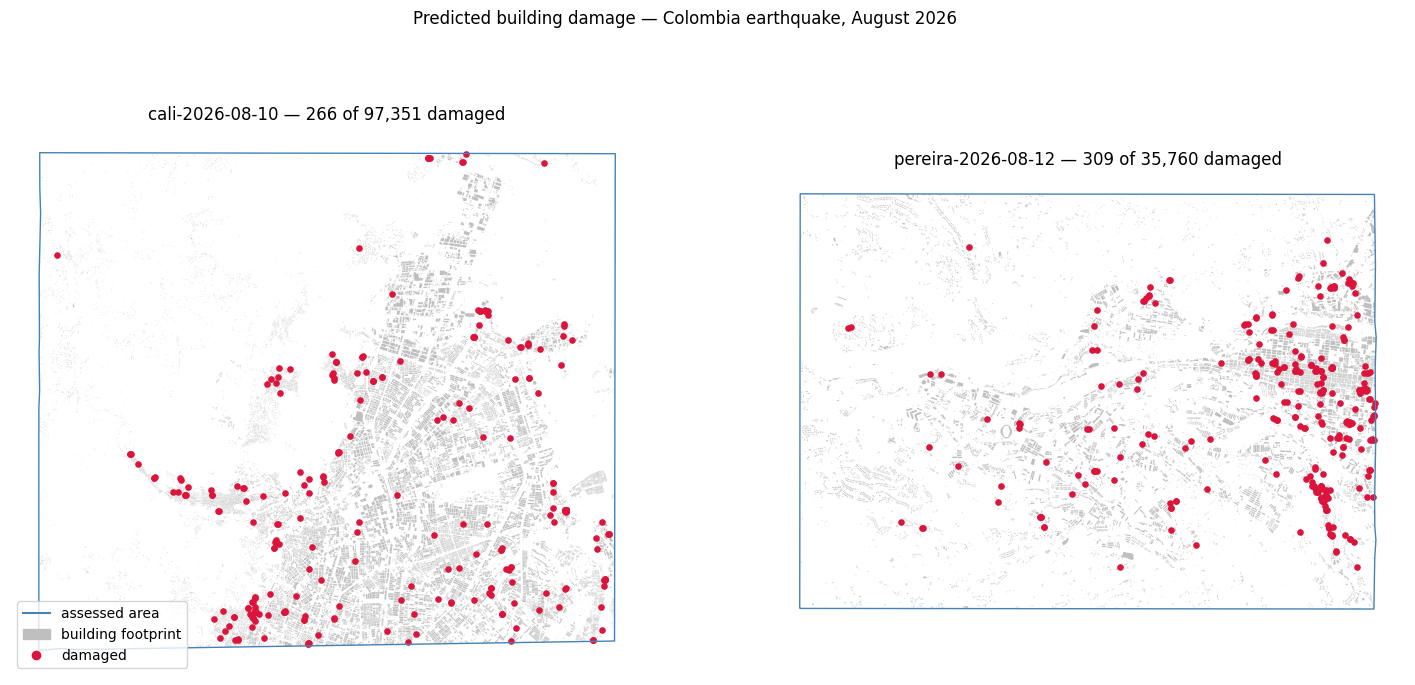

In [8]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, item in zip(axes, items):
    city = gdf[gdf["item"] == item.id]
    mask = geopandas.read_file(item.assets["valid-area-mask"].href).to_crs(gdf.crs)

    mask.boundary.plot(ax=ax, color="steelblue", linewidth=1.0)
    city.plot(ax=ax, color="0.75", linewidth=0)
    city[city["damaged"] == 1].centroid.plot(ax=ax, color="crimson", markersize=14)

    ax.set_title(f"{item.id} — {city['damaged'].sum()} of {len(city):,} damaged")
    ax.set_axis_off()

axes[0].legend(
    handles=[
        Line2D([], [], color="steelblue", label="assessed area"),
        Patch(color="0.75", label="building footprint"),
        Line2D([], [], color="crimson", marker="o", linestyle="", label="damaged"),
    ],
    loc="lower left",
)
fig.suptitle("Predicted building damage — Colombia earthquake, August 2026", y=0.93)


### The prediction raster

The `visual` asset is the model's raw output: a single-band, paletted Cloud-Optimized GeoTIFF where each pixel carries a class code. The file ships its own color table, so we can read the class colors straight out of the GeoTIFF rather than inventing our own.


In [9]:
CLASS_LABELS = {
    0: "no data",
    1: "background",
    2: "building",
    3: "damaged building",
    4: "unknown",
}

pereira = {item.id: item for item in items}["pereira-2026-08-12"]

with rasterio.open(pereira.assets["visual"].href) as src:
    print("shape:     ", src.shape)
    print("dtype:     ", src.dtypes[0])
    print("CRS:       ", src.crs)
    print("resolution:", tuple(round(r, 3) for r in src.res), "meters")
    print("nodata:    ", src.nodata)
    color_table = src.colormap(1)

pd.DataFrame(
    [
        {"value": value, "class": label, "RGBA": color_table[value]}
        for value, label in CLASS_LABELS.items()
    ]
)


shape:      (22209, 30921)
dtype:      uint8
CRS:        EPSG:32618
resolution: (0.336, 0.336) meters
nodata:     0.0


,value,class,RGBA
0,0,no data,"(0, 0, 0, 0)"
1,1,background,"(0, 0, 0, 255)"
2,2,building,"(0, 255, 0, 255)"
3,3,damaged building,"(255, 0, 0, 255)"
4,4,unknown,"(128, 128, 128, 255)"


At roughly 31,000 × 22,000 pixels the raster is far too large — and the damage far too sparse — to be worth plotting whole. Instead we zoom in on the densest cluster of damaged buildings and use a **windowed read**, so only the GeoTIFF tiles covering that neighborhood are fetched over the network.


In [10]:
footprints = gdf[gdf["item"] == pereira.id]
damaged = footprints[footprints["damaged"] == 1].geometry.centroid

# Center the view on the damaged building with the most damaged neighbors nearby.
neighbors = damaged.buffer(250).apply(
    lambda region: damaged.sindex.query(region, predicate="contains").size
)
center = damaged.iloc[int(neighbors.argmax())]
bounds = (center.x - 300, center.y - 300, center.x + 300, center.y + 300)

with rasterio.open(pereira.assets["visual"].href) as src:
    window = rasterio.windows.from_bounds(*bounds, transform=src.transform)
    predictions = src.read(1, window=window)
    left, bottom, right, top = rasterio.windows.bounds(window, src.transform)

predictions.shape


(1784, 1784)

Finally we render that window with the GeoTIFF's own color table and overlay the Overture footprints, which makes it easy to see how the per-pixel prediction rolls up into the per-building `damaged` flag. Note that the footprints represent the state of the ground *before* the earthquake, so they won't always line up exactly with the post-event imagery the model ran on.


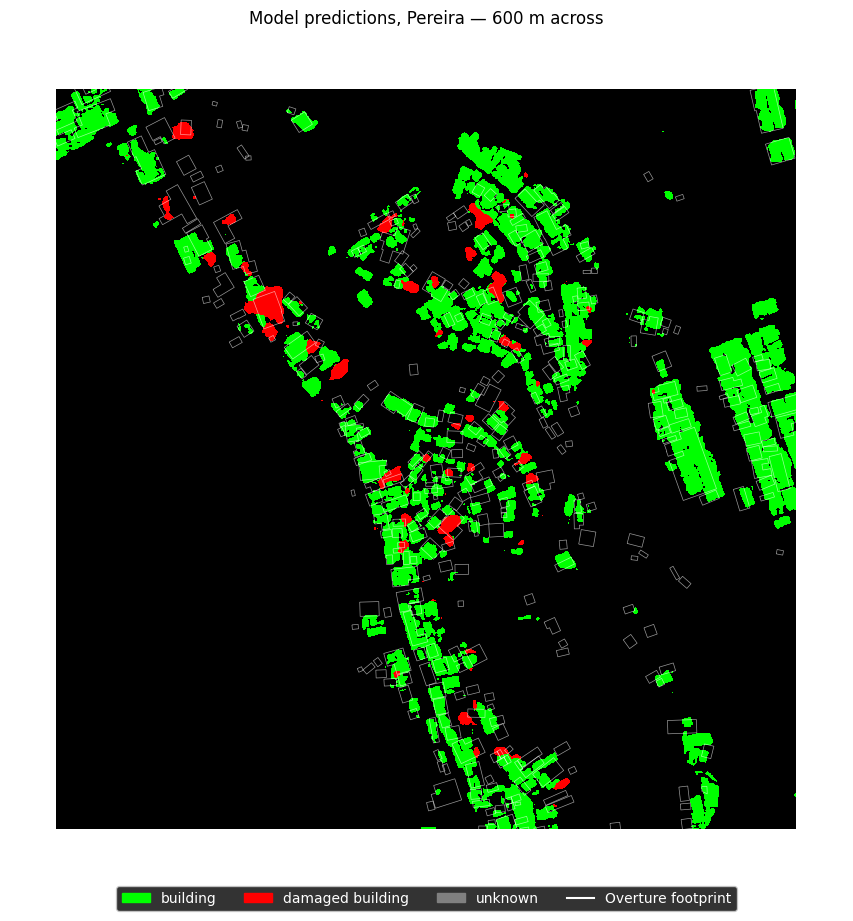

In [11]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(
    [tuple(band / 255 for band in color_table[value][:3]) for value in CLASS_LABELS]
)

fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(
    predictions,
    extent=(left, right, bottom, top),
    cmap=cmap,
    vmin=0,
    vmax=max(CLASS_LABELS),
    interpolation="nearest",
)
footprints.cx[left:right, bottom:top].boundary.plot(
    ax=ax, color="white", linewidth=0.5, alpha=0.6
)
ax.legend(
    handles=[
        Patch(color=cmap(value), label=label)
        for value, label in CLASS_LABELS.items()
        if value > 1
    ]
    + [Line2D([], [], color="white", label="Overture footprint")],
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=4,
    facecolor="black",
    labelcolor="white",
)
ax.set_title("Model predictions, Pereira — 600 m across")
ax.set_axis_off()
